# Aerial Guardian – Part 1: Dataset Verification + YOLO finetuning

### 1. Dataset Structure Verification

In [1]:
from pathlib import Path

TRAIN_ROOT = Path("/kaggle/input/assign-vis/VisDrone2019-MOT-train/VisDrone2019-MOT-train")
VAL_ROOT   = Path("/kaggle/input/assign-vis/VisDrone2019-MOT-val/VisDrone2019-MOT-val")

print(TRAIN_ROOT.exists())
print(VAL_ROOT.exists())

True
True


#### 2. Count Sequences

In [2]:
train_seq = sorted((TRAIN_ROOT/"sequences").glob("*"))
val_seq   = sorted((VAL_ROOT/"sequences").glob("*"))

print("Train sequences:", len(train_seq))
print("Validation sequences:", len(val_seq))

print("\nTrain:")
for s in train_seq:
    print(s.name)

print("\nValidation:")
for s in val_seq:
    print(s.name)

Train sequences: 56
Validation sequences: 7

Train:
uav0000013_00000_v
uav0000013_01073_v
uav0000013_01392_v
uav0000020_00406_v
uav0000071_03240_v
uav0000072_04488_v
uav0000072_05448_v
uav0000072_06432_v
uav0000076_00720_v
uav0000079_00480_v
uav0000084_00000_v
uav0000099_02109_v
uav0000124_00944_v
uav0000126_00001_v
uav0000138_00000_v
uav0000140_01590_v
uav0000143_02250_v
uav0000145_00000_v
uav0000150_02310_v
uav0000218_00001_v
uav0000222_03150_v
uav0000239_03720_v
uav0000239_12336_v
uav0000243_00001_v
uav0000244_01440_v
uav0000248_00001_v
uav0000263_03289_v
uav0000264_02760_v
uav0000266_03598_v
uav0000266_04830_v
uav0000270_00001_v
uav0000273_00001_v
uav0000278_00001_v
uav0000279_00001_v
uav0000281_00460_v
uav0000288_00001_v
uav0000289_00001_v
uav0000289_06922_v
uav0000295_02300_v
uav0000300_00000_v
uav0000307_00000_v
uav0000308_00000_v
uav0000308_01380_v
uav0000309_00000_v
uav0000315_00000_v
uav0000316_01288_v
uav0000323_01173_v
uav0000326_01035_v
uav0000329_04715_v
uav0000342_04692_

#### 3. Count Images

In [3]:
from pathlib import Path

def count_images(root):

    total = 0

    for seq in (root/"sequences").iterdir():
        total += len(list(seq.glob("*.jpg")))

    return total

print("Train Images:", count_images(TRAIN_ROOT))
print("Val Images  :", count_images(VAL_ROOT))

Train Images: 24201
Val Images  : 2846


#### 4. Dataset Categories

In [4]:
from collections import Counter

counter = Counter()

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            parts = line.strip().split(',')

            if len(parts) < 8:
                continue

            cls = int(parts[7])

            counter[cls] += 1

print(counter)

Counter({4: 505301, 1: 234305, 10: 102819, 2: 94396, 0: 62369, 5: 46940, 3: 40255, 6: 30498, 7: 28338, 8: 13011, 9: 9653, 11: 1474})


#### 5. Pedestrian Statistics

In [5]:
pedestrian_count = 0

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            parts = line.strip().split(',')

            if len(parts) < 8:
                continue

            if int(parts[7]) == 1:
                pedestrian_count += 1

print("Pedestrian boxes:", pedestrian_count)

Pedestrian boxes: 234305


#### 6. Bounding Box Size Analysis

In [6]:
import numpy as np

widths = []
heights = []
areas = []

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            parts = line.strip().split(',')

            if len(parts) < 8:
                continue

            cls = int(parts[7])

            if cls != 1:
                continue

            w = float(parts[4])
            h = float(parts[5])

            widths.append(w)
            heights.append(h)
            areas.append(w*h)

widths = np.array(widths)
heights = np.array(heights)
areas = np.array(areas)

print("Total:", len(widths))

print("\nWidth")
print("Min :", widths.min())
print("Mean:", widths.mean())
print("Max :", widths.max())

print("\nHeight")
print("Min :", heights.min())
print("Mean:", heights.mean())
print("Max :", heights.max())

Total: 234305

Width
Min : 4.0
Mean: 27.043144619192933
Max : 191.0

Height
Min : 4.0
Mean: 56.354956146902545
Max : 225.0


#### 7. Tiny / Small / Medium Distribution

In [7]:
tiny = 0
small = 0
medium = 0
large = 0

for w,h in zip(widths, heights):

    if w < 32 and h < 32:
        tiny += 1

    elif w < 64 and h < 64:
        small += 1

    elif w < 128 and h < 128:
        medium += 1

    else:
        large += 1

total = len(widths)

print(f"Tiny   : {tiny} ({100*tiny/total:.2f}%)")
print(f"Small  : {small} ({100*small/total:.2f}%)")
print(f"Medium : {medium} ({100*medium/total:.2f}%)")
print(f"Large  : {large} ({100*large/total:.2f}%)")

Tiny   : 34053 (14.53%)
Small  : 121919 (52.03%)
Medium : 75960 (32.42%)
Large  : 2373 (1.01%)


#### 8. Resolution Analysis

In [8]:
import cv2
from collections import Counter

resolutions = Counter()

for seq in (TRAIN_ROOT/"sequences").iterdir():

    imgs = sorted(seq.glob("*.jpg"))

    if len(imgs) == 0:
        continue

    img = cv2.imread(str(imgs[0]))

    h,w = img.shape[:2]

    resolutions[(w,h)] += len(imgs)

print("Resolutions:\n")

for k,v in resolutions.items():
    print(k, ":", v)

Resolutions:

(1904, 1071) : 12895
(1344, 756) : 5645
(1920, 1080) : 721
(2688, 1512) : 3505
(2720, 1530) : 473
(1360, 765) : 962


#### 9. Crowd Density Analysis

In [9]:
from collections import defaultdict
import numpy as np

persons_per_frame = []

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    frame_dict = defaultdict(int)

    with open(txt) as f:

        for line in f:

            p = line.strip().split(',')

            if len(p) < 8:
                continue

            frame_id = int(p[0])

            cls = int(p[7])

            if cls == 1:
                frame_dict[frame_id] += 1

    persons_per_frame.extend(frame_dict.values())

persons_per_frame = np.array(persons_per_frame)

print("Mean :", persons_per_frame.mean())
print("Median :", np.median(persons_per_frame))
print("Max :", persons_per_frame.max())

Mean : 10.93656646751307
Median : 8.0
Max : 77


#### 10. Visual Inspection

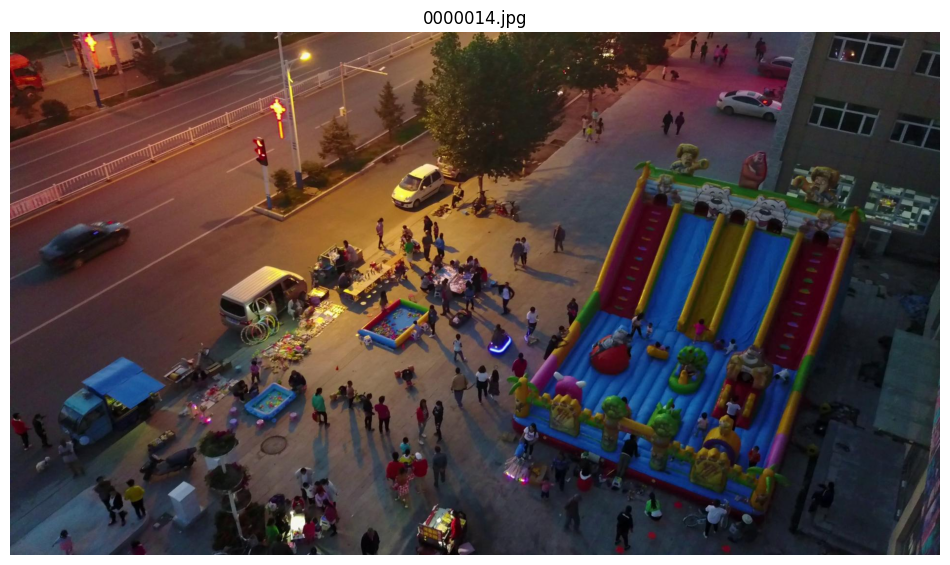

In [10]:
import cv2
import random
import matplotlib.pyplot as plt

seq = random.choice(list((TRAIN_ROOT/"sequences").iterdir()))

img_path = random.choice(list(seq.glob("*.jpg")))

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.title(img_path.name)
plt.axis("off")
plt.show()

#### 11. verify valid Sequences

In [11]:
valid = 0
ignored = 0

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            p = line.strip().split(",")

            if len(p) < 10:
                continue

            cls = int(p[7])

            score = int(p[6])

            if cls == 1:

                if score == 0:
                    ignored += 1
                else:
                    valid += 1

print("Valid pedestrian boxes :", valid)
print("Ignored pedestrian boxes:", ignored)

Valid pedestrian boxes : 234305
Ignored pedestrian boxes: 0


In [12]:
from pathlib import Path
from collections import defaultdict
import pandas as pd

train_ann_dir = TRAIN_ROOT / "annotations"

results = []

for ann_file in sorted(train_ann_dir.glob("*.txt")):

    pedestrian_count = 0
    frames_with_pedestrians = set()

    with open(ann_file, "r") as f:

        for line in f:

            p = line.strip().split(",")

            if len(p) < 8:
                continue

            frame_id = int(p[0])
            cls = int(p[7])

            if cls == 1:   # pedestrian

                pedestrian_count += 1
                frames_with_pedestrians.add(frame_id)

    results.append({
        "sequence": ann_file.stem,
        "pedestrian_boxes": pedestrian_count,
        "frames_with_pedestrians": len(frames_with_pedestrians)
    })

df_train = pd.DataFrame(results)

print("="*80)
print("TRAIN SEQUENCES")
print("="*80)

display(df_train.sort_values("pedestrian_boxes"))

print("\nSequences with NO pedestrians:")
display(df_train[df_train["pedestrian_boxes"] == 0])

print("\nTotal sequences:", len(df_train))
print("Sequences with pedestrians:",
      (df_train["pedestrian_boxes"] > 0).sum())
print("Sequences without pedestrians:",
      (df_train["pedestrian_boxes"] == 0).sum())

TRAIN SEQUENCES


,sequence,pedestrian_boxes,frames_with_pedestrians
26,uav0000263_03289_v,0,0
19,uav0000218_00001_v,4,4
27,uav0000264_02760_v,157,157
20,uav0000222_03150_v,304,304
29,uav0000266_04830_v,348,116
40,uav0000307_00000_v,414,414
1,uav0000013_01073_v,536,58
39,uav0000300_00000_v,1069,463
22,uav0000239_12336_v,1090,341
4,uav0000071_03240_v,1225,181



Sequences with NO pedestrians:


,sequence,pedestrian_boxes,frames_with_pedestrians
26,uav0000263_03289_v,0,0



Total sequences: 56
Sequences with pedestrians: 55
Sequences without pedestrians: 1


In [13]:
from pathlib import Path
from collections import defaultdict
import pandas as pd

val_ann_dir = VAL_ROOT / "annotations"

results = []

for ann_file in sorted(val_ann_dir.glob("*.txt")):

    pedestrian_count = 0
    frames_with_pedestrians = set()

    with open(ann_file, "r") as f:

        for line in f:

            p = line.strip().split(",")

            if len(p) < 8:
                continue

            frame_id = int(p[0])
            cls = int(p[7])

            if cls == 1:

                pedestrian_count += 1
                frames_with_pedestrians.add(frame_id)

    results.append({
        "sequence": ann_file.stem,
        "pedestrian_boxes": pedestrian_count,
        "frames_with_pedestrians": len(frames_with_pedestrians)
    })

df_val = pd.DataFrame(results)

print("="*80)
print("VALIDATION SEQUENCES")
print("="*80)

display(df_val.sort_values("pedestrian_boxes"))

print("\nSequences with NO pedestrians:")
display(df_val[df_val["pedestrian_boxes"] == 0])

print("\nTotal sequences:", len(df_val))
print("Sequences with pedestrians:",
      (df_val["pedestrian_boxes"] > 0).sum())
print("Sequences without pedestrians:",
      (df_val["pedestrian_boxes"] == 0).sum())

VALIDATION SEQUENCES


,sequence,pedestrian_boxes,frames_with_pedestrians
5,uav0000305_00000_v,540,166
3,uav0000182_00000_v,845,239
4,uav0000268_05773_v,891,527
6,uav0000339_00001_v,3273,275
2,uav0000137_00458_v,3792,233
1,uav0000117_02622_v,8164,349
0,uav0000086_00000_v,14899,464



Sequences with NO pedestrians:


,sequence,pedestrian_boxes,frames_with_pedestrians



Total sequences: 7
Sequences with pedestrians: 7
Sequences without pedestrians: 0


In [14]:
print("\nTRAIN PEDESTRIAN COUNTS")
display(df_train[["sequence","pedestrian_boxes"]]
        .sort_values("pedestrian_boxes")
        .head(15))

print("\nVALIDATION PEDESTRIAN COUNTS")
display(df_val[["sequence","pedestrian_boxes"]]
        .sort_values("pedestrian_boxes"))


TRAIN PEDESTRIAN COUNTS


,sequence,pedestrian_boxes
26,uav0000263_03289_v,0
19,uav0000218_00001_v,4
27,uav0000264_02760_v,157
20,uav0000222_03150_v,304
29,uav0000266_04830_v,348
40,uav0000307_00000_v,414
1,uav0000013_01073_v,536
39,uav0000300_00000_v,1069
22,uav0000239_12336_v,1090
4,uav0000071_03240_v,1225



VALIDATION PEDESTRIAN COUNTS


,sequence,pedestrian_boxes
5,uav0000305_00000_v,540
3,uav0000182_00000_v,845
4,uav0000268_05773_v,891
6,uav0000339_00001_v,3273
2,uav0000137_00458_v,3792
1,uav0000117_02622_v,8164
0,uav0000086_00000_v,14899


In [15]:
counter = {}

for txt in (TRAIN_ROOT/"annotations").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            p = line.strip().split(",")

            if len(p) < 8:
                continue

            cls = int(p[7])

            if cls in [1,2]:

                counter[cls] = counter.get(cls,0) + 1

print(counter)

{1: 234305, 2: 94396}


## Preprocessing the dataset

In [16]:
import os

OUTPUT_ROOT = "/kaggle/working/VisDrone_Person_YOLO"

folders = [
    f"{OUTPUT_ROOT}/images/train",
    f"{OUTPUT_ROOT}/images/val",
    f"{OUTPUT_ROOT}/labels/train",
    f"{OUTPUT_ROOT}/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created.")

Folders created.


In [17]:
from pathlib import Path

TRAIN_ROOT = Path("/kaggle/input/assign-vis/VisDrone2019-MOT-train/VisDrone2019-MOT-train")
VAL_ROOT   = Path("/kaggle/input/assign-vis/VisDrone2019-MOT-val/VisDrone2019-MOT-val")

OUTPUT_ROOT = Path("/kaggle/working/VisDrone_Person_YOLO")

PERSON_CLASSES = [1, 2]

REMOVE_SEQUENCES = {
    "uav0000263_03289_v"
}

In [18]:
import shutil
from collections import defaultdict
from tqdm import tqdm
import cv2

def convert_split(root_path, split_name):

    seq_dir = root_path / "sequences"
    ann_dir = root_path / "annotations"

    img_out = OUTPUT_ROOT / "images" / split_name
    lbl_out = OUTPUT_ROOT / "labels" / split_name

    sequences = sorted(seq_dir.iterdir())

    total_images = 0
    total_boxes = 0

    for seq in tqdm(sequences, desc=f"Processing {split_name}"):

        seq_name = seq.name

        if seq_name in REMOVE_SEQUENCES:
            print(f"Skipping {seq_name}")
            continue

        ann_file = ann_dir / f"{seq_name}.txt"

        frame_boxes = defaultdict(list)

        with open(ann_file, "r") as f:

            for line in f:

                p = line.strip().split(",")

                if len(p) < 8:
                    continue

                frame_id = int(p[0])

                x = float(p[2])
                y = float(p[3])

                w = float(p[4])
                h = float(p[5])

                cls = int(p[7])

                if cls not in PERSON_CLASSES:
                    continue

                frame_boxes[frame_id].append(
                    [x, y, w, h]
                )

        images = sorted(seq.glob("*.jpg"))

        for img_path in images:

            frame_id = int(img_path.stem)

            img = cv2.imread(str(img_path))

            H, W = img.shape[:2]

            new_name = f"{seq_name}_{frame_id:07d}"

            shutil.copy(
                str(img_path),
                str(img_out / f"{new_name}.jpg")
            )

            label_file = lbl_out / f"{new_name}.txt"

            with open(label_file, "w") as lf:

                for box in frame_boxes.get(frame_id, []):

                    x, y, w, h = box

                    xc = (x + w/2) / W
                    yc = (y + h/2) / H

                    bw = w / W
                    bh = h / H

                    lf.write(
                        f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n"
                    )

                    total_boxes += 1

            total_images += 1

    print(f"\n{split_name.upper()} SUMMARY")
    print("Images:", total_images)
    print("Boxes :", total_boxes)

In [19]:
convert_split(TRAIN_ROOT, "train")

Processing train:  46%|████▋     | 26/56 [03:17<05:33, 11.12s/it]

Skipping uav0000263_03289_v


Processing train: 100%|██████████| 56/56 [07:52<00:00,  8.44s/it]


TRAIN SUMMARY
Images: 23476
Boxes : 328701


In [20]:
convert_split(VAL_ROOT, "val")

Processing val: 100%|██████████| 7/7 [01:22<00:00, 11.74s/it]


VAL SUMMARY
Images: 2846
Boxes : 50312


In [21]:
yaml_text = f"""
path: {OUTPUT_ROOT}

train: images/train
val: images/val

names:
  0: person
"""

with open(OUTPUT_ROOT / "visdrone_person.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)


path: /kaggle/working/VisDrone_Person_YOLO

train: images/train
val: images/val

names:
  0: person



In [22]:
import os

print("Train Images:",
      len(os.listdir(OUTPUT_ROOT / "images/train")))

print("Train Labels:",
      len(os.listdir(OUTPUT_ROOT / "labels/train")))

print("Val Images:",
      len(os.listdir(OUTPUT_ROOT / "images/val")))

print("Val Labels:",
      len(os.listdir(OUTPUT_ROOT / "labels/val")))

Train Images: 23476
Train Labels: 23476
Val Images: 2846
Val Labels: 2846


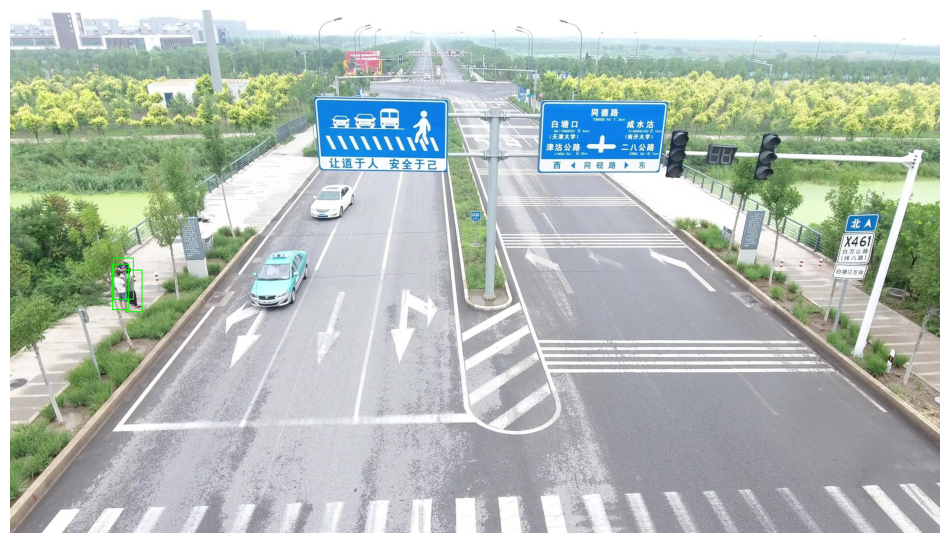

In [23]:
import random
import cv2
import matplotlib.pyplot as plt

img_name = random.choice(
    os.listdir(OUTPUT_ROOT / "images/train")
)

img_path = OUTPUT_ROOT / "images/train" / img_name
lbl_path = OUTPUT_ROOT / "labels/train" / img_name.replace(".jpg",".txt")

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W = img.shape[:2]

with open(lbl_path) as f:

    for line in f:

        _, xc, yc, bw, bh = map(float, line.split())

        x1 = int((xc - bw/2)*W)
        y1 = int((yc - bh/2)*H)

        x2 = int((xc + bw/2)*W)
        y2 = int((yc + bh/2)*H)

        cv2.rectangle(
            img,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Finetuning YOLO

In [24]:
import os

TRAIN_IMAGES = "/kaggle/working/VisDrone_Person_YOLO/images/train"
VAL_IMAGES   = "/kaggle/working/VisDrone_Person_YOLO/images/val"

print("Train Images:", len(os.listdir(TRAIN_IMAGES)))
print("Val Images:", len(os.listdir(VAL_IMAGES)))

Train Images: 23476
Val Images: 2846


In [25]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 32.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [26]:
import torch

print(torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

2
0 Tesla T4
1 Tesla T4


In [27]:
from ultralytics import YOLO

DATA_YAML = "/kaggle/working/VisDrone_Person_YOLO/visdrone_person.yaml"

model = YOLO("yolo11m.pt")

results = model.train(
    data=DATA_YAML,

    # Training
    epochs=25,
    patience=6,
    batch=16,
    imgsz=1152,

    # Optimization
    optimizer="AdamW",
    lr0=5e-4,
    lrf=0.01,
    cos_lr=True,

    # Augmentations
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.3,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    fliplr=0.5,
    scale=0.5,

    # Hardware
    device=[0,1],      # Use both T4 GPUs
    workers=8,

    # Saving
    save=True,
    save_period=5,

    # Output folder
    project="/kaggle/working/runs/detect/DronePersonTracking",
    name="YOLO11m_VisDrone"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/VisDrone_Person_YOLO/visdrone_person.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5

In [28]:
import shutil
from pathlib import Path

RUN_DIR = Path(
    "/kaggle/working/runs/detect/DronePersonTracking/YOLO11m_VisDrone"
)

BEST_SRC = RUN_DIR / "weights" / "best.pt"
LAST_SRC = RUN_DIR / "weights" / "last.pt"

BEST_DST = "/kaggle/working/best_visdrone_person_yolo11m.pt"
LAST_DST = "/kaggle/working/last_visdrone_person_yolo11m.pt"

shutil.copy(BEST_SRC, BEST_DST)
shutil.copy(LAST_SRC, LAST_DST)

print("Saved:")
print(BEST_DST)
print(LAST_DST)

Saved:
/kaggle/working/best_visdrone_person_yolo11m.pt
/kaggle/working/last_visdrone_person_yolo11m.pt


In [29]:
import shutil

RUN_FOLDER = "/kaggle/working/runs/detect/DronePersonTracking/YOLO11m_VisDrone"

shutil.make_archive(
    "/kaggle/working/YOLO11m_VisDrone_COMPLETE",
    "zip",
    RUN_FOLDER
)

print("ZIP created:")
print("/kaggle/working/YOLO11m_VisDrone_COMPLETE.zip")

ZIP created:
/kaggle/working/YOLO11m_VisDrone_COMPLETE.zip
